Получение данных:

In [3]:
!pip install kagglehub

In [4]:
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


Словарь имя файла - путь к файлу:

In [5]:
import os
from glob import glob

imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x
                     for x in glob(os.path.join(path, '*', '*.jpg'))}

Наименования видов поражения:

In [6]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

Таблица признаков и путей к файлам:

In [7]:
import pandas as pd

skin_df = pd.read_csv(os.path.join(path, 'HAM10000_metadata.csv'))
skin_df['path'] = skin_df['image_id'].map(imageid_path_dict.get)
skin_df['cell_type'] = skin_df['dx'].map(lesion_type_dict.get)
skin_df['cell_type_idx'] = pd.Categorical(skin_df['cell_type']).codes
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2


Индексы видов поражения:

In [8]:
leison_type_index_mapping = dict(enumerate(pd.Categorical(skin_df['cell_type']).categories))
leison_type_index_mapping

{0: 'Actinic keratoses',
 1: 'Basal cell carcinoma',
 2: 'Benign keratosis-like lesions',
 3: 'Dermatofibroma',
 4: 'Melanocytic nevi',
 5: 'Melanoma',
 6: 'Vascular lesions'}

Уменьшение разрешения изображений:

In [9]:
import numpy as np
from PIL import Image
from tqdm import tqdm

def load_and_resize(paths, size=(128, 96)):
    images = [np.asarray(Image.open(p).resize(size)) for p in tqdm(paths, desc="Уменьшение разрешения изображений")]
    return np.array(images)

X = load_and_resize(skin_df["path"].values)
X.shape

Уменьшение разрешения изображений: 100%|██████████| 10015/10015 [02:44<00:00, 61.02it/s]


(10015, 96, 128, 3)

Разбиение на обучающую и тестовую выборку:

In [10]:
from sklearn.model_selection import train_test_split

y = skin_df['cell_type_idx']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Размер обучающей выборки (X_train): {X_train.shape}")
print(f"Размер тестовой выборки (X_test): {X_test.shape}")

Размер обучающей выборки (X_train): (8012, 96, 128, 3)
Размер тестовой выборки (X_test): (2003, 96, 128, 3)


Нормализация:

In [11]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

Выделение валидационной выборки из тестовой:

In [12]:
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, test_size = 0.2, random_state=42)
X_train.shape

(6409, 96, 128, 3)

One-hot encoding целевой переменной:

In [13]:
from keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes = 7)
y_test = to_categorical(y_test, num_classes = 7)
y_validate = to_categorical(y_validate, num_classes = 7)
y_validate.shape

(1603, 7)

Простая CNN-модель:

In [14]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras import backend as K
import itertools
from keras.layers import BatchNormalization

from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split

import math

input_shape = X_train.shape[-3:]
num_classes = 7

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 128, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 128, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,211,815 (12.25 MB)

 Trainable params: 3,211,815 (12.25 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        verbose=1,
        min_lr=1e-6
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])

model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    shuffle=True,
    callbacks=callbacks,
    validation_data=(X_validate, y_validate),
    verbose = 1
)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.6630 - loss: 1.0694 - val_accuracy: 0.6769 - val_loss: 0.9447 - learning_rate: 0.0010
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6694 - loss: 0.9538 - val_accuracy: 0.6968 - val_loss: 0.9045 - learning_rate: 0.0010
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6789 - loss: 0.9066 - val_accuracy: 0.6850 - val_loss: 0.8842 - learning_rate: 0.0010
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6862 - loss: 0.8428 - val_accuracy: 0.7012 - val_loss: 0.8368 - learning_rate: 0.0010
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7007 - loss: 0.8171 - val_accuracy: 0.7068 - val_loss: 0.8327 - learning_rate: 0.0010
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7053 - loss: 0.7905 - val_accuracy: 0.7199 - val_loss: 0.8681 - learning_rate: 0.0010
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7112 - 

Метрики качества:

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
                               precision    recall  f1-score   support

            Actinic keratoses       0.34      0.17      0.23        65
         Basal cell carcinoma       0.38      0.58      0.46       103
Benign keratosis-like lesions       0.45      0.29      0.35       220
               Dermatofibroma       0.00      0.00      0.00        23
             Melanocytic nevi       0.78      0.93      0.85      1341
                     Melanoma       0.42      0.11      0.18       223
             Vascular lesions       0.79      0.39      0.52        28

                     accuracy                           0.71      2003
                    macro avg       0.45      0.35      0.37      2003
                 weighted avg       0.66      0.71      0.66      2003



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


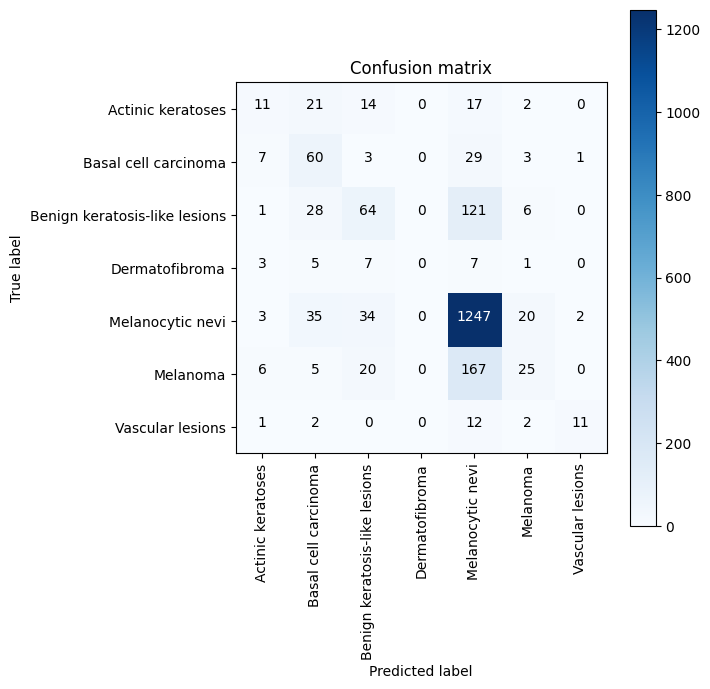

In [16]:
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize=(7, 7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

def print_classification_report(y_true, y_pred, target_names):
  print(classification_report(y_true, np.argmax(y_pred, axis=1), target_names=target_names))

def print_results(model, X_test, y_test, target_names):
  y_pred = model.predict(X_test)
  y_pred_classes = np.argmax(y_pred, axis=1)
  y_true = np.argmax(y_test, axis=1)
  confusion_mtx = confusion_matrix(y_true, y_pred_classes)
  plot_confusion_matrix(confusion_mtx, target_names)
  print_classification_report(y_true, y_pred, target_names)

print_results(model, X_test, y_test, list(leison_type_index_mapping.values()))

CNN-модель с аугментацией данных и балансировкой классов:

In [22]:
from sklearn.utils.class_weight import compute_class_weight

unique_classes = y.unique()
weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y)
weights = np.clip(weights, a_min=1.0, a_max=10.0)
class_weight_dict = dict(zip(unique_classes, weights))
class_weight_dict

{np.int8(2): np.float64(1.301832835044846),
 np.int8(4): np.float64(1.0),
 np.int8(3): np.float64(10.0),
 np.int8(5): np.float64(1.2854575792581184),
 np.int8(6): np.float64(10.0),
 np.int8(1): np.float64(2.78349082823791),
 np.int8(0): np.float64(4.375273044997815)}

In [23]:
from keras.layers import Activation, Input, RandomFlip, RandomRotation, RandomBrightness

model = Sequential()

model.add(Input(shape=input_shape))
model.add(RandomFlip("horizontal_and_vertical"))
model.add(RandomRotation(0.15))
# model.add(RandomBrightness(0.1))

model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(num_classes, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 96, 128, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 96, 128, 3)     │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 96, 128, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 96, 128, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 96, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 96, 128, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 96, 128, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 96, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 48, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 48, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 48, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 48, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 48, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 24, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64)             │             

 Total params: 3,212,839 (12.26 MB)

 Trainable params: 3,212,327 (12.25 MB)

 Non-trainable params: 512 (2.00 KB)

In [24]:
model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss="categorical_crossentropy", metrics=["accuracy"])

model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    shuffle=True,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    validation_data=(X_validate, y_validate),
    verbose = 1
)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.4264 - loss: 2.6820 - val_accuracy: 0.1085 - val_loss: 2.8695 - learning_rate: 1.0000e-04
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.5803 - loss: 2.0258 - val_accuracy: 0.2402 - val_loss: 1.9274 - learning_rate: 1.0000e-04
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.6588 - loss: 1.7916 - val_accuracy: 0.6500 - val_loss: 1.1743 - learning_rate: 1.0000e-04
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - accuracy: 0.6925 - loss: 1.6320 - val_accuracy: 0.7286 - val_loss: 0.9017 - learning_rate: 1.0000e-04
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.7035 - loss: 1.5298 - val_accuracy: 0.7149 - val_loss: 0.9087 - learning_rate: 1.0000e-04
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.7179 - loss: 1.4779 - val_accuracy: 0.7461 - val_loss: 0.7852 - learning_rate: 1.0000e-04
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 16s 7

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
                               precision    recall  f1-score   support

            Actinic keratoses       0.41      0.74      0.53        65
         Basal cell carcinoma       0.65      0.50      0.56       103
Benign keratosis-like lesions       0.60      0.48      0.53       220
               Dermatofibroma       0.36      0.35      0.36        23
             Melanocytic nevi       0.85      0.94      0.89      1341
                     Melanoma       0.65      0.27      0.38       223
             Vascular lesions       0.58      0.54      0.56        28

                     accuracy                           0.77      2003
                    macro avg       0.58      0.54      0.54      2003
                 weighted avg       0.76      0.77      0.76      2003



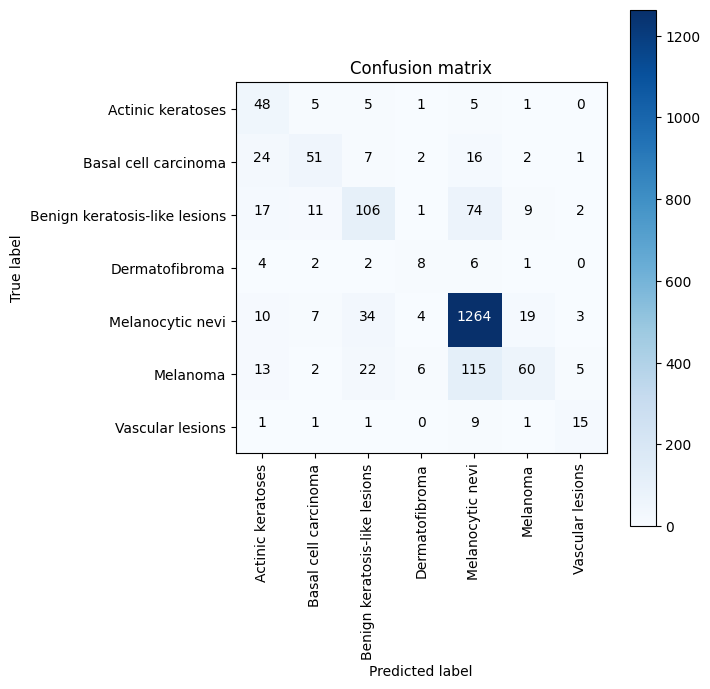

In [25]:
print_results(model, X_test, y_test, list(leison_type_index_mapping.values()))